# Setup, załadowanie bibliotek i obrazów

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

text1 = cv2.imread('A.bmp')
imgB = cv2.imread('B.bmp')
imgC = cv2.imread('C.bmp')
imageBin1 = cv2.imread('binary1.bmp')
imageBin3 = cv2.imread('binary3.bmp')
imgText = cv2.imread('text1.bmp')


# Zadanie 1

## Zadanie 1.a - Binaryzacja obrazu z ustalonym progiem

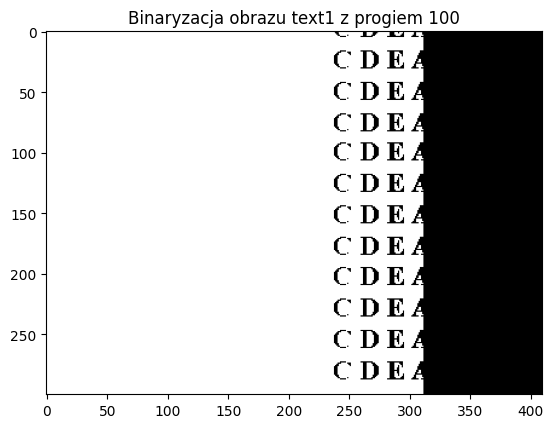

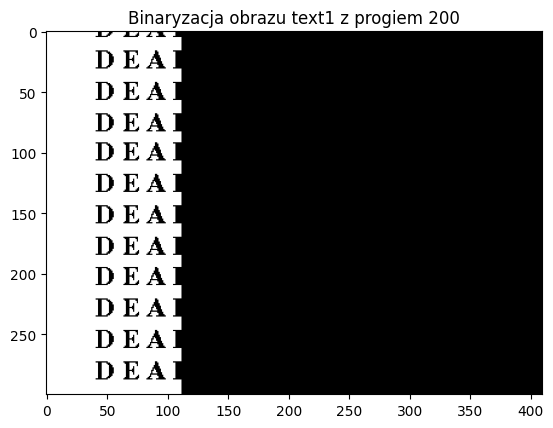

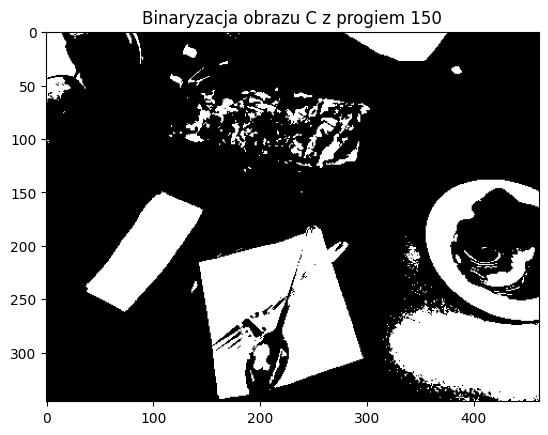

In [16]:
def binaryzacjaProgiem(img, prog):
    """Funkcja binaryzująca obraz z ustalonym progiem.
    Args:
        img: obraz MONOCHROMATYCZNY do binaryzacji 
        prog: próg binaryzacji"""
    x,y,_ = img.shape
    binarizedImg = np.zeros((x,y,3), dtype=np.uint8)
    plt.show()
    for i in range(x):
        for j in range(y):
            if img[i][j][0] < prog:
                binarizedImg[i][j] = [0,0,0]
            else:
                binarizedImg[i][j] = [255,255,255]

    return binarizedImg

## Zadanie 1.a - Binaryzacja obrazu z ustalonym progiem

plt.imshow(binaryzacjaProgiem(imgText, 100))
plt.title('Binaryzacja obrazu text1 z progiem 100')
plt.show()

plt.imshow(binaryzacjaProgiem(imgText, 200))
plt.title('Binaryzacja obrazu text1 z progiem 200')
plt.show()

plt.imshow(binaryzacjaProgiem(imgC, 150))
plt.title('Binaryzacja obrazu C z progiem 150')
plt.show()


## Zadanie 1.b - binaryzacja obrazu z progiem wyznaczonym metodą Otsu

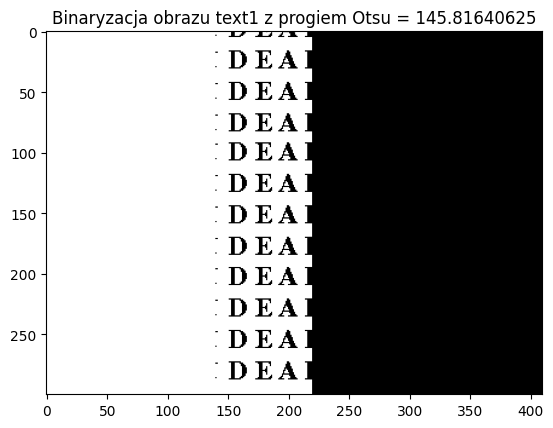

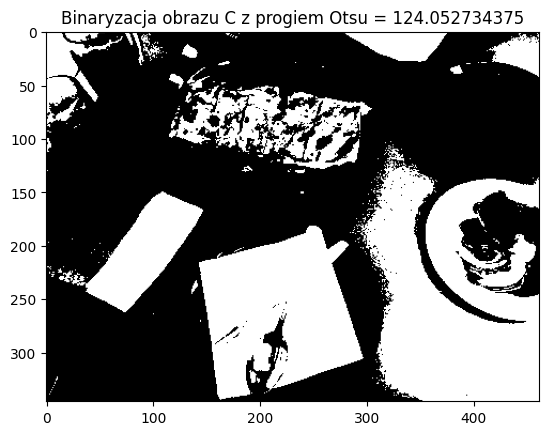

In [17]:
def otsuThreshold(img):
    # Obrazy wejściowe są 8-bitowe, więc liczba poziomów szarości wynosi 256
    hist, bin_edges = np.histogram(img, bins=256)
    
    # Calculate centers of bins
    bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2.
    
    # Iterate over all thresholds (indices) and get the probabilities w1(t), w2(t)
    weight1 = np.cumsum(hist)
    weight2 = np.cumsum(hist[::-1])[::-1]
    
    # Get the class means mu0(t)
    mean1 = np.cumsum(hist * bin_mids) / weight1
    # Get the class means mu1(t)
    mean2 = (np.cumsum((hist * bin_mids)[::-1]) / weight2[::-1])[::-1]
    
    inter_class_variance = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:]) ** 2
    
    # Maximize the inter_class_variance function val
    index_of_max_val = np.argmax(inter_class_variance)
    
    threshold = bin_mids[:-1][index_of_max_val]
    return threshold

calculatedThresholdA = otsuThreshold(imgText)
binarizedImgText_Otsu = binaryzacjaProgiem(imgText, calculatedThresholdA)

calculatedThresholdC = otsuThreshold(imgC)
binarizedImgC_Otsu = binaryzacjaProgiem(imgC, calculatedThresholdC)
plt.imshow(binarizedImgText_Otsu)
plt.title('Binaryzacja obrazu text1 z progiem Otsu = ' + str(calculatedThresholdA))
plt.show()
plt.imshow(binarizedImgC_Otsu)
plt.title('Binaryzacja obrazu C z progiem Otsu = ' + str(calculatedThresholdC))
plt.show()


## Zadanie 1.c - lokalna binaryzacja obrazu jako średnia z otoczenia 21x21 pikseli dla każdego piksela.
Jeśli pixel leży zbyt blisko którejś krawędzi obrazu, rozmiar otoczenia powinien być
odpowiednio mniejszy (pomijamy pixele, które wychodziłyby poza granice obrazu).

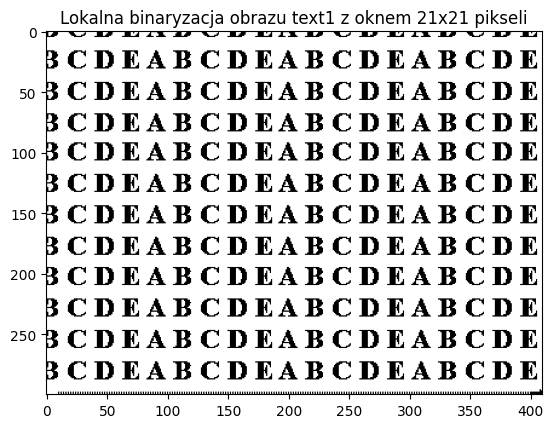

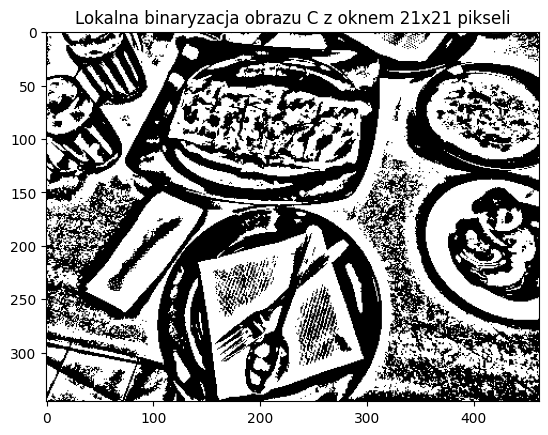

In [19]:
def localBinaryzation(img, window_size):
    x,y,_ = img.shape
    binarizedImg = np.zeros((x,y,3), dtype=np.uint8)
    offset = window_size // 2
    
    for i in range(x):
        for j in range(y):
            
            x_start = max(0, i - offset)
            x_end = min(x, i + offset + 1)
            y_start = max(0, j - offset)
            y_end = min(y, j + offset + 1)
            
            neighborhood = img[x_start:x_end, y_start:y_end]
            
            average = np.average(neighborhood)
            
            if img[i][j][0] < average:
                binarizedImg[i][j] = [0,0,0]
            else:
                binarizedImg[i][j] = [255,255,255]

    return binarizedImg

binarizedImgText_Local = localBinaryzation(imgText, 21)
binarizedImgC_Local = localBinaryzation(imgC, 21)
plt.imshow(binarizedImgText_Local)
plt.title('Lokalna binaryzacja obrazu text1 z oknem 21x21 pikseli')
plt.show()

plt.imshow(binarizedImgC_Local)
plt.title('Lokalna binaryzacja obrazu C z oknem 21x21 pikseli')
plt.show()

# Zadanie 2